# Multi-Snapshot GP Emulation -- Cluster Profiles
Training and emulation across multiple snapshots (redshifts) for cluster gas profiles:
CGD, CPP (Pressure), CTP (Temperature), CEP (Entropy), CEEP (Electron Entropy), CGED (Electron Density), CMP (Metallicity), CYP (Compton-y).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os

from cosmo_hydro_emu.pca import *
from cosmo_hydro_emu.viz import *
from cosmo_hydro_emu.load_hacc import *
from cosmo_hydro_emu.emu import *
from cosmo_hydro_emu.gp import *
from cosmo_hydro_emu.snapshot_utils import *

# Configuration & Parameters

In [2]:
DirIn = '../data/scidac-400MPC_RUNS_5SG_2COSMO_PARAM-extracts_20260323/'

start_sim_idx = 1
num_sims = 39
exp_variance = 0.999

z_initial = 200

do_train = True

In [3]:
def read_params(fileIn):
    params_all = np.loadtxt(fileIn, delimiter=",", skiprows=1)
    start_sim_idx = 1
    end_sim_idx = 40
    print('Loaded file with params: ', params_all.shape)
    return params_all[start_sim_idx:end_sim_idx]

fileIn = '/home/nramachandra/Projects/Hydro_runs/CosmoHydro/data/FinalDesign.txt'
params32 = read_params(fileIn)

seed_mass_scale = 1e6
vkin_scale = 1e4
eps_scale = 1e1

params32[:, 2] = params32[:, 2] / seed_mass_scale
params32[:, 3] = params32[:, 3] / vkin_scale
params32[:, 4] = params32[:, 4] / eps_scale

PARAM_NAME = ['$\\kappa_\\text{w}$',
              '$e_\\text{w}$',
              '$M_\\text{seed}/10^{6}$',
              '$v_\\text{kin}/10^{4}$',
              '$\\epsilon_\\text{kin}/10^{1}$',
              '$\\omega_\\text{m}$',
              '$\\sigma_\\text{8}$']

print('params32 shape:', params32.shape)

Loaded file with params:  (110, 7)
params32 shape: (39, 7)


In [4]:
# Train/test split: hold out 5 sims for proper validation
test_sim_indices = np.array([3, 11, 19, 27, 35])
train_sim_indices = np.array([i for i in range(num_sims) if i not in test_sim_indices])

params_train = params32[train_sim_indices]
params_test = params32[test_sim_indices]

print(f'Train: {len(train_sim_indices)} sims, Test: {len(test_sim_indices)} sims')

Train: 34 sims, Test: 5 sims


# Snapshot Setup

Number of snapshots: 11
Snapshot IDs: [205, 224, 247, 275, 310, 355, 415, 479, 498, 567, 624]
Redshift range: z = 0.00 to 2.00
Scale factor range: a = 0.333 to 1.000


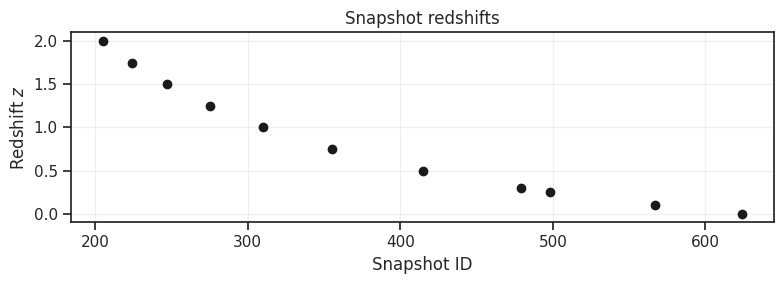

In [5]:
z_all, a_all = get_snapshot_redshifts(SNAPSHOT_IDS, z_initial=z_initial)

print(f'Number of snapshots: {len(SNAPSHOT_IDS)}')
print(f'Snapshot IDs: {SNAPSHOT_IDS}')
print(f'Redshift range: z = {z_all[-1]:.2f} to {z_all[0]:.2f}')
print(f'Scale factor range: a = {a_all[0]:.3f} to {a_all[-1]:.3f}')

plt.figure(figsize=(8, 3))
plt.scatter(SNAPSHOT_IDS, z_all, c='k', zorder=5)
plt.xlabel('Snapshot ID')
plt.ylabel('Redshift $z$')
plt.title('Snapshot redshifts')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Load Data -- All Profiles at All Snapshots

In [6]:
# Define all profile types: (short_name, file_prefix)
PROFILE_CONFIGS = [
    ('CGD',  'ClusterGasDensityProfile'),
    ('CPP',  'ClusterGasPressureProfile'),
    ('CTP',  'ClusterGasTemperatureProfile'),
    ('CEP',  'ClusterGasEntropyProfile'),
    ('CEEP', 'ClusterElectronEntropyProfile'),
    ('CGED', 'ClusterGasElectronDensityProfile'),
    ('CMP',  'ClusterGasMetallicityProfile'),
    ('CYP',  'ClusterGasYProfile'),
]

profile_data = {}

for short_name, file_prefix in PROFILE_CONFIGS:
    radius, arr = read_profile_all_snaps(DirIn, num_sims, SNAPSHOT_IDS, file_prefix,
                                         start_sim_idx=start_sim_idx)
    profile_data[short_name] = arr
    print(f'{short_name}: radius {radius.shape}, arr {arr.shape}')

print(f'\nShared radius array: {radius.shape} (range {radius.min():.4f} to {radius.max():.2f})')

CGD: radius (19,), arr (39, 11, 19)
CPP: radius (19,), arr (39, 11, 19)
CTP: radius (19,), arr (39, 11, 19)
CEP: radius (19,), arr (39, 11, 19)
CEEP: radius (19,), arr (39, 11, 19)
CGED: radius (19,), arr (39, 11, 19)
CMP: radius (19,), arr (39, 11, 19)
CYP: radius (19,), arr (39, 11, 19)

Shared radius array: (19,) (range 0.0154 to 2.74)


# Visualize -- All Profiles at Multiple Snapshots

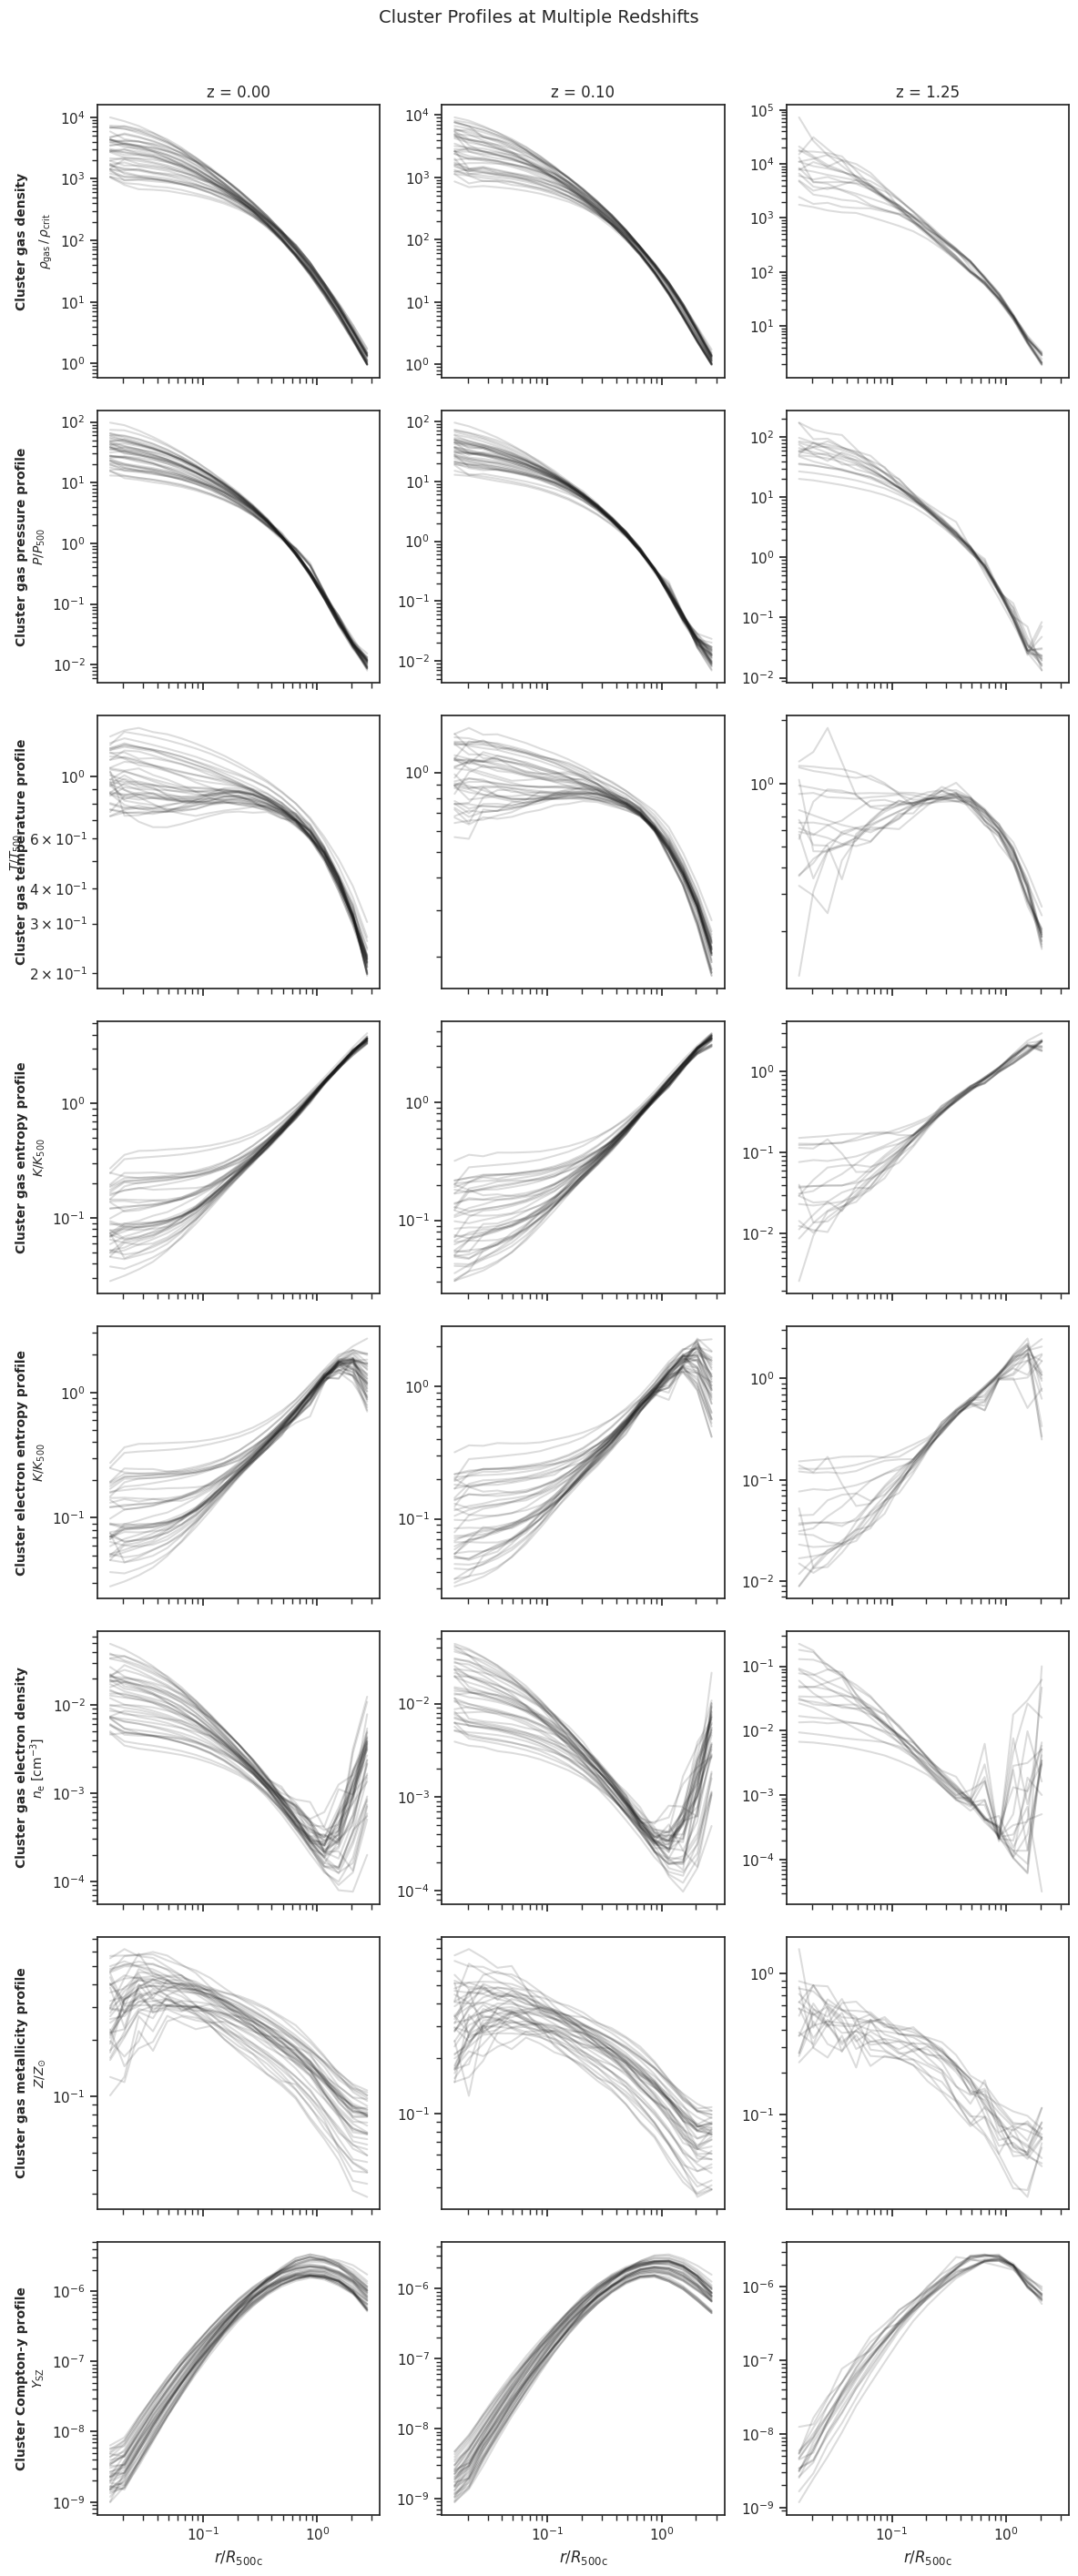

In [7]:
snap_indices_to_plot = [-1, -2, -8]  # cluster profiles valid from z~0.5 onward

n_profiles = len(PROFILE_CONFIGS)
n_snaps_plot = len(snap_indices_to_plot)

fig, axes = plt.subplots(n_profiles, n_snaps_plot,
                         figsize=(4*n_snaps_plot, 3.5*n_profiles),
                         sharex=True)

for row, (short_name, _) in enumerate(PROFILE_CONFIGS):
    plt_str = plot_strings(short_name)
    arr = profile_data[short_name]

    for col, snap_idx in enumerate(snap_indices_to_plot):
        ax = axes[row, col]
        z_snap = z_all[snap_idx]

        for sim_i in range(num_sims):
            ax.plot(radius, arr[sim_i, snap_idx, :], 'k-', alpha=0.15)

        ax.set_xscale('log')
        ax.set_yscale('log')

        if row == 0:
            ax.set_title(f'z = {z_snap:.2f}', fontsize=12)
        if row == n_profiles - 1:
            ax.set_xlabel(plt_str[1])
        if col == 0:
            ax.set_ylabel(plt_str[2], fontsize=10)
            ax.annotate(plt_str[0], xy=(0, 0.5), xytext=(-60, 0),
                        textcoords='offset points', xycoords='axes fraction',
                        fontsize=10, rotation=90, va='center', ha='center',
                        fontweight='bold')

plt.suptitle('Cluster Profiles at Multiple Redshifts', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('../plots/profiles_all_multiz.png', bbox_inches='tight', dpi=150)
plt.show()

# Emulate All Profiles -- All Snapshots
All cluster profiles share the same radius array and the same redshift validity range as CGD.

In [8]:
# Radius cut (shared by all profiles, same as CGD)
rlim1, rlim2 = mass_conds('CGD')
rad_cond = np.where((radius > rlim1) & (radius < rlim2))[0]
profile_y_ind = radius[rad_cond]

print(f'Radius cut: {rlim1} < r/R500c < {rlim2}')
print(f'Bins after cut: {len(rad_cond)}')

# Cluster profile data is all NaN at high z (snap indices 0-5);
# valid from index 6 onward (snaps 415-624, z <= ~0.5)
profile_z_start_idx = 6
z_index_range = np.arange(len(SNAPSHOT_IDS))[profile_z_start_idx:]

Radius cut: 0.015 < r/R500c < 2.75
Bins after cut: 19


In [ ]:
# Train, load, and validate all profiles
profile_models = {}  # short_name -> (model_list, data_list, y_vals)

for short_name, _ in PROFILE_CONFIGS:
    print(f'\n{"="*60}')
    print(f'Processing {short_name}: {plot_strings(short_name)[0]}')
    print(f'{"="*60}')

    # Data prep
    y_vals = profile_data[short_name][:, :, rad_cond]
    print(f'  Training data shape: {y_vals.shape}')

    model_dir = f'model/{short_name}/'

    # Train
    if do_train:
        os.makedirs(model_dir, exist_ok=True)
        print(f'  Training for z_index_range={z_index_range} '
              f'(snaps {[SNAPSHOT_IDS[i] for i in z_index_range]})')
        do_gp_train_multiple(model_dir=model_dir,
                             p_train_all=params_train,
                             y_vals_all=y_vals[train_sim_indices],
                             y_ind_all=profile_y_ind,
                             z_index_range=z_index_range)
    else:
        print('  Training skipped. Set do_train=True to train.')

    # Load
    model_list, data_list = load_model_multiple(
        model_dir=model_dir,
        p_train_all=params_train,
        y_vals_all=y_vals[train_sim_indices],
        y_ind_all=profile_y_ind,
        z_index_range=z_index_range
    )

    profile_models[short_name] = (model_list, data_list, y_vals)


Processing CGD: Cluster gas density
  Training data shape: (39, 11, 19)
  Training for z_index_range=[ 6  7  8  9 10] (snaps [415, 479, 498, 567, 624])
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]]
lamUz
[[5. 5. 5. 5. 5.]]
lamWs
[[100. 100. 100. 100. 100.]]
lamWOs
[[100.]]


Step size tuning: 100%|██████████| 50/50 [00:22<00:00,  2.25it/s]


Done with tune_step_size.
Selected step sizes:
betaU
[[0.45915863 1.52969039 0.4706236  0.30253804 0.42545319]
 [0.19993415 0.20448839 0.07352914 0.83367414 1.23862084]
 [0.30355898 6.64801802 0.4377219  1.5311883  2.63197092]
 [0.0193267  0.62618675 3.08025795 1.59791698 3.13705878]
 [1.49513035 2.0667008  2.07596043 1.4183312  1.48722683]
 [1.0350732  2.85965267 4.04329761 2.51588593 0.79428049]
 [0.66469279 4.51029771 0.05739557 2.69112747 2.92433095]
 [0.41548781 2.52280317 0.36866376 1.22375324 0.93829929]]
lamUz
[[1.23659431 1.41888472 1.28946228 1.72008738 1.71500389]]
lamWs
[[3459.66276836 4731.24387944 4362.65992566 5628.99293813 4067.77631674]]
lamWOs
[[979.54671263]]


MCMC sampling: 100%|██████████| 1000/1000 [00:17<00:00, 56.22it/s]


Model saved to model/CGD/multivariate_model_z_index6.pkl
Training complete for snapshot 6
Model saved at model/CGD/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1]]
lamUz
[[5. 5. 5. 5. 5.]]
lamWs
[[100. 100. 100. 100. 100.]]
lamWOs
[[100.]]


...

MCMC sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Done with tune_step_size.
Selected step sizes:
betaU
[[0.78906376 0.60060382 0.15375266 0.51369073 0.80142264 1.06926364
  0.28496674 0.28446587 0.38475553]
 [0.09046763 0.23106618 0.66573109 0.98467762 1.10385473 4.28039922
  3.45513288 2.84002132 4.19992314]
 [0.18970205 0.44334808 0.46726228 0.33575982 3.18777031 0.35023451
  2.94817098 2.4415659  0.10080494]
 [0.34288729 0.12663568 0.12450403 1.0764141  0.06564927 0.56329498
  0.13141933 0.37603758 3.38015246]
 [1.57471291 0.65845344 0.0237206  0.35924427 3.53797469 0.44430384
  0.93420658 2.14380641 1.0736366 ]
 [2.19016327 0.34898711 0.21171698 0.54698583 0.3704553  2.3943328
  2.58171952 0.09790048 2.4406082 ]
 [1.2913631  1.46748237 2.02511454 1.00422178 1.13570992 2.61249949
  3.57782023 2.01834266 2.13595149]
 [0.06963662 2.39900898 2.93024342 0.71860216 0.47083797 2.90277749
  0.11957618 0.8116144  0.36190395]]
lamUz
[[1.9287718  1.52641043 1.35910911 1.45625931 1.52099391 1.7092857
  1.87973981 2.05384582 1.85081089]]
lamWs

Step size tuning:   0%|          | 0/50 [00:00<?, ?it/s]

Model saved to model/CEP/multivariate_model_z_index10.pkl
Training complete for snapshot 10
Model saved at model/CEP/
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
Number of models loaded: 5 from: model/CEP/

Processing CEEP: Cluster electron entropy profile
  Training data shape: (39, 11, 19)
  Training for z_index_range=[ 6  7  8  9 10] (snaps [415, 479, 498, 567, 624])
Starting tune_step_sizes...
Default step sizes:
betaU
[[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]]
lamUz
[[5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]]
lamWs
[[100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]]
lamWOs
[[100.]]


Step size tuning:  96%|█████████▌| 48/50 [00:47<00:01,  1.01it/s]

# Validation -- All Profiles at z=0 (Subplot Grid)

In [ ]:
n_profiles = len(PROFILE_CONFIGS)
ncols = 4
nrows = int(np.ceil(n_profiles / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes_flat = axes.flatten()

input_params = params_test[:3]
colors = ['b', 'r', 'g']

for idx, (short_name, _) in enumerate(PROFILE_CONFIGS):
    ax = axes_flat[idx]
    model_list, data_list, y_vals = profile_models[short_name]
    plt_str = plot_strings(short_name)

    snap_idx_test = -1  # last model = z=0
    target_vals = y_vals[test_sim_indices[:3], -1, :]

    pred_mean, pred_quant = emulate(model_list[snap_idx_test], input_params)

    for j in range(pred_mean.shape[1]):
        ax.plot(profile_y_ind, target_vals[j], c=colors[j], ls='-', alpha=0.8)
        ax.plot(profile_y_ind, pred_mean[:, j], c=colors[j], ls='--', alpha=0.8)
        ax.fill_between(profile_y_ind,
                        pred_quant[:, j, 0], pred_quant[:, j, 1],
                        color=colors[j], alpha=0.15)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(plt_str[0], fontsize=11)
    ax.set_xlabel(plt_str[1])
    ax.set_ylabel(plt_str[2])

# Hide unused axes
for idx in range(n_profiles, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle(f'Validation at z = {z_all[-1]:.2f} (held-out test set)\n'
             f'Solid = simulation, Dashed = emulated', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../plots/profiles_all_validation_z0.png', bbox_inches='tight', dpi=150)
plt.show()

# Validation -- Individual Profiles (with Error Panels)

In [ ]:
input_params = params_test[:3]

for short_name, _ in PROFILE_CONFIGS:
    model_list, data_list, y_vals = profile_models[short_name]
    plt_str = plot_strings(short_name)

    snap_idx_test = -1
    target_vals = y_vals[test_sim_indices[:3], -1, :]
    pred_mean, pred_quant = emulate(model_list[snap_idx_test], input_params)

    validation_plot(profile_y_ind, target_vals, pred_mean, pred_quant,
                    *plt_str, None, None, 'log', 'log', (0.05, 1.2))
    plt.suptitle(f'{short_name} Validation at z = {z_all[-1]:.2f} (held-out test set)')
    plt.savefig(f'../plots/{short_name}_multiz_valid.png', bbox_inches='tight')

# Redshift Interpolation -- All Profiles

In [ ]:
profile_z_all = z_all[profile_z_start_idx:]
test_params = params_test[:3]

n_profiles = len(PROFILE_CONFIGS)
ncols = 4
nrows = int(np.ceil(n_profiles / ncols))

for j in range(3):
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes_flat = axes.flatten()

    z_grid = np.linspace(profile_z_all[-2], profile_z_all[1], 200)
    norm = mcolors.Normalize(vmin=z_grid.min(), vmax=z_grid.max())
    cmap = cm.coolwarm

    for idx, (short_name, _) in enumerate(PROFILE_CONFIGS):
        ax = axes_flat[idx]
        model_list, data_list, y_vals = profile_models[short_name]
        plt_str = plot_strings(short_name)

        for z_test in z_grid:
            input_with_z = np.hstack([test_params[j:j+1], np.array([[z_test]])])
            pred, _ = emu_redshift(input_with_z, model_list, data_list, profile_z_all)
            ax.plot(profile_y_ind, pred.flatten(), alpha=0.7,
                    color=cmap(norm(z_test)), lw=0.8)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(plt_str[0], fontsize=11)
        ax.set_xlabel(plt_str[1])
        ax.set_ylabel(plt_str[2])

    for idx in range(n_profiles, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes_flat[:n_profiles].tolist(), shrink=0.6, pad=0.02)
    cbar.set_label('Redshift $z$')

    fig.suptitle(f'All profiles across redshift (test sim {j})', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(f'../plots/profiles_all_z_sweep_sim{j}.png', bbox_inches='tight', dpi=150)
    plt.show()

# Sensitivity: Parameter Variation at z=0 (All Profiles)

In [ ]:
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'

numPlots = 300
allMax = np.max(params32, axis=0)
allMin = np.min(params32, axis=0)
allMean = np.mean(params32, axis=0)

# Parameters to vary: sigma8 (6), kappa_w (0), epsilon_kin (4)
params_to_vary = [6, 0, 4]
param_labels = [
    r'$\mathrm{Cosmology:}\ \sigma_8$',
    r'$\mathrm{Subgrid:}\ \kappa_\mathrm{w}$',
    r'$\mathrm{Subgrid:}\ \epsilon_\mathrm{kin}$',
]

n_profiles = len(PROFILE_CONFIGS)
n_params = len(params_to_vary)

fig, axes = plt.subplots(n_profiles, n_params,
                         figsize=(5*n_params, 3.5*n_profiles),
                         sharex=True)

cmap = cm.coolwarm
bbox_props = dict(boxstyle='round,pad=0.3', facecolor='grey', alpha=0.2, edgecolor='blue')

for row, (short_name, _) in enumerate(PROFILE_CONFIGS):
    model_list, data_list, y_vals = profile_models[short_name]
    plt_str = plot_strings(short_name)

    for col, paramNo in enumerate(params_to_vary):
        ax = axes[row, col]
        para_range = np.linspace(allMin[paramNo], allMax[paramNo], numPlots)
        norm = mcolors.Normalize(vmin=allMin[paramNo], vmax=allMax[paramNo])

        for plotID in range(numPlots):
            para_plot = np.copy(allMean)
            para_plot[paramNo] = para_range[plotID]
            pred, _ = emulate(model_list[-1], para_plot)
            ax.plot(profile_y_ind, pred.flatten(), lw=0.8,
                    color=cmap(norm(para_range[plotID])), alpha=0.7)

        ax.set_xscale('log')
        ax.set_yscale('log')

        if row == 0:
            ax.set_title(param_labels[col], fontsize=11)
        if row == n_profiles - 1:
            ax.set_xlabel(plt_str[1])
        if col == 0:
            ax.set_ylabel(plt_str[2], fontsize=10)
            ax.annotate(short_name, xy=(0, 0.5), xytext=(-50, 0),
                        textcoords='offset points', xycoords='axes fraction',
                        fontsize=11, rotation=90, va='center', ha='center',
                        fontweight='bold')

        # Colorbar for rightmost column
        if col == n_params - 1:
            sm = cm.ScalarMappable(norm=norm, cmap=cmap)
            sm.set_array([])

# Add colorbars for each parameter column
for col, paramNo in enumerate(params_to_vary):
    norm = mcolors.Normalize(vmin=allMin[paramNo], vmax=allMax[paramNo])
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes[:, col].tolist(), shrink=0.6, pad=0.02)
    cbar.set_label(PARAM_NAME[paramNo], fontsize=13)

fig.suptitle('Parameter Sensitivity at z=0 (all cluster profiles)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../plots/profiles_all_sensitivity_z0.png', bbox_inches='tight', dpi=150)
plt.show()

# Sensitivity: Redshift Variation (All Profiles)

In [ ]:
profile_z_all = z_all[profile_z_start_idx:]

n_profiles = len(PROFILE_CONFIGS)
ncols = 4
nrows = int(np.ceil(n_profiles / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes_flat = axes.flatten()

z_grid = np.linspace(profile_z_all[-2], profile_z_all[1], numPlots)
norm_z = mcolors.Normalize(vmin=z_grid.min(), vmax=z_grid.max())

for idx, (short_name, _) in enumerate(PROFILE_CONFIGS):
    ax = axes_flat[idx]
    model_list, data_list, y_vals = profile_models[short_name]
    plt_str = plot_strings(short_name)

    for z_val in z_grid:
        input_with_z = np.hstack([allMean.reshape(1, -1), np.array([[z_val]])])
        pred, _ = emu_redshift(input_with_z, model_list, data_list, profile_z_all)
        ax.plot(profile_y_ind, pred.flatten(), lw=0.8,
                color=cmap(norm_z(z_val)), alpha=0.7)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(plt_str[0], fontsize=11)
    ax.set_xlabel(plt_str[1])
    ax.set_ylabel(plt_str[2])

for idx in range(n_profiles, len(axes_flat)):
    axes_flat[idx].set_visible(False)

sm = cm.ScalarMappable(norm=norm_z, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes_flat[:n_profiles].tolist(), shrink=0.6, pad=0.02)
cbar.set_label(r'Redshift $z$', fontsize=13)

fig.suptitle('Redshift sensitivity (fiducial parameters)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../plots/profiles_all_z_sensitivity.png', bbox_inches='tight', dpi=150)
plt.show()